<a href="https://colab.research.google.com/github/donkey-king-kong/CSCI-4907---NLU/blob/main/(GWU)_CSCI_4907_NLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Hate Speech in Tweets - Cyberbullying
Group Members:
> - Zhan You Lau
> - Yu Chen Law
> - Kieran E Kai Voo
> - Joshua, Tse Ern Foo

# Introduction
Social media has become ubiquitous in our everyday communication which contributes to the increased prevalence of cyberbullying. However, cyberbullying detection is particularly challenging in a multilabel setting as harmful content may belong to multiple overlapping categories like threats, insults, or implicit aggression. These categories often rely on subtle linguistic cues such as sarcasm and contextual ambiguity. This makes accurate classification difficult.

## Problem Formulation
Our project examines how different modeling approaches handle the complexities of multilabel cyberbullying detection as well as evaluates their strengths and limitations beyond overall performance metrics.

### Key Objective
- Perform data preparation, preprocessing, and exploratory analysis
- Implement classical machine learning models and Bi-LSTM for comparison
- Evaluate and compare model performance using multilabel metrics
- Conduct structured error analysis to examine linguistic failure cases

## Trigger Warning
These tweets either describe a bullying event or are the offense themselves, therefore explore it to the point where you feel comfortable.

In [18]:
import pandas as pd
df = pd.read_csv('cyberbullying_tweets.csv')
df.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


## Data Preparation & Cleaning
The following actions are performed to the data present in our dataset to bring a uniformity and remove any stray characters to improve effeciency of our model.

In [17]:
import string
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# Function to make text lowercase
def make_lowercase(text):
    lower = text.lower()
    return lower

# Function to remove mentions (@username) from text
def remove_mentions(text):
    clean_text = re.sub(r'@\S+', '', text)
    return clean_text

# Function to remove punctuation from text
def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    clean_text = text.translate(translator)
    return clean_text

# Function to remove URLs from text
def remove_url(text):
    clean_text = re.sub(r'https?://\S+|www\.\S+', '', text)
    return clean_text

# Function to remove extra whitespaces from text
def remove_extraspace(text):
    words = text.split()
    updated_text = " ".join(words)
    return updated_text

# Function to remove stopwords from text
def remove_stopwords(text):
    tweet_words = text.split()
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in tweet_words if word not in stop_words]
    filtered_tweet = " ".join(filtered_words)
    return filtered_tweet

# Function to remove HTML characters (e.g., &) from text
def remove_strayHTML(text):
    clean_text = text = re.sub(r'&\S+;', '', text)
    return clean_text

# Function to remove numbers from text
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Function to remove picture links (e.g., pic.twitter.com) from text
def remove_piclinks(text):
    return re.sub(r'pic\.twitter\.com/\S+', '', text)

# Function to remove short words (length <= 2) from text
def remove_shortwords(text):
    words = text.split()
    long_words = [word for word in words if len(word) > 2]
    return ' '.join(long_words)

## Testing Data Cleaning Functions

In [11]:
def test_make_lowercase():
    assert make_lowercase("HeLLo!") == "hello!"
    assert make_lowercase("") == ""

def test_remove_mentions():
    assert remove_mentions("@bob hi") == " hi"
    assert remove_mentions("hi @bob") == "hi "
    assert remove_mentions("hi") == "hi"

def test_remove_punctuation():
    assert remove_punctuation("hi, world!") == "hi world"
    assert remove_punctuation("no_punct") == "nopunct"
    assert remove_punctuation("") == ""

def test_remove_url():
    assert remove_url("visit http://example.com now") == "visit  now"
    assert remove_url("visit https://example.com now") == "visit  now"
    assert remove_url("visit www.example.com now") == "visit  now"

def test_remove_extraspace():
    assert remove_extraspace("  hi   there  ") == "hi there"
    assert remove_extraspace("hi") == "hi"
    assert remove_extraspace("") == ""

def test_remove_stopwords():
    _ = stopwords.words("english")
    assert remove_stopwords("this is a test") == "test"
    assert remove_stopwords("the quick brown fox") == "quick brown fox"

def test_remove_strayHTML():
    assert remove_strayHTML("Tom &amp; Jerry") == "Tom  Jerry"
    assert remove_strayHTML("no html") == "no html"

def test_remove_numbers():
    assert remove_numbers("a1b2c3") == "abc"
    assert remove_numbers("2026-02-25") == "--"
    assert remove_numbers("no nums") == "no nums"

def test_remove_piclinks():
    assert remove_piclinks("check pic.twitter.com/abc") == "check "
    assert remove_piclinks("no pic link") == "no pic link"

def test_remove_shortwords():
    assert remove_shortwords("I am at NTU") == "NTU"
    assert remove_shortwords("to be or not to be") == "not"

def run_all_tests():
    tests = [
        test_make_lowercase,
        test_remove_mentions,
        test_remove_punctuation,
        test_remove_url,
        test_remove_extraspace,
        test_remove_stopwords,
        test_remove_strayHTML,
        test_remove_numbers,
        test_remove_piclinks,
        test_remove_shortwords,
    ]
    for t in tests:
        t()
    print(f"Passed {len(tests)} tests")

run_all_tests()

Passed 10 tests


In [13]:
# A single function to preprocess the entire tweets data
def clean_text(text):
    text=make_lowercase(text)
    text=remove_stopwords(text)
    text=remove_mentions(text)
    text=remove_strayHTML(text)
    text=remove_punctuation(text)
    text=remove_url(text)
    text=remove_extraspace(text)
    text=remove_numbers(text)
    text=remove_piclinks(text)
    text=remove_shortwords(text)
    return text

In [20]:
# Apply the clean_text function to each tweet in the 'tweet_text' column of the DataFrame
cleaned_tweets = []

for tweet in df['tweet_text']:
    cleaned = clean_text(tweet)
    cleaned_tweets.append(cleaned)

df['tweet_clean'] = cleaned_tweets
df.head(10)

,tweet_text,cyberbullying_type,tweet_clean
0,"In other words #katandandre, your food was cra...",not_cyberbullying,words katandandre food crapilicious mkr
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,aussietv white mkr theblock imacelebrityau tod...
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,classy whore red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,meh thanks heads concerned another angry dude ...
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,isis account pretending kurdish account like i...
5,"@Raja5aab @Quickieleaks Yes, the test of god i...",not_cyberbullying,yes test god good bad indifferent weird whatev...
6,Itu sekolah ya bukan tempat bully! Ga jauh kay...,not_cyberbullying,itu sekolah bukan tempat bully jauh kaya neraka
7,Karma. I hope it bites Kat on the butt. She is...,not_cyberbullying,karma hope bites kat butt nasty mkr
8,@stockputout everything but mostly my priest,not_cyberbullying,everything mostly priest
9,Rebecca Black Drops Out of School Due to Bully...,not_cyberbullying,rebecca black drops school due bullying


## Exploratory Data Analysis
To analyse and visualze the data we have cleaned in order to understand its underlying patterns, relationships and anomalies. We will be using data visualization techniques in hopes of generating insights that could help us better understand the data before applying any models or conducting any hypothesis testing.

### Preliminary Examination - The Numbers Game
The "numbers game" is used in our exploratory data analysis where we systematically examine the numerical data to identify patterns, trends and anmoalies. 

Here, we plot the number of tweets belonging to each category in the dataset as well as their relative percentages.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sb

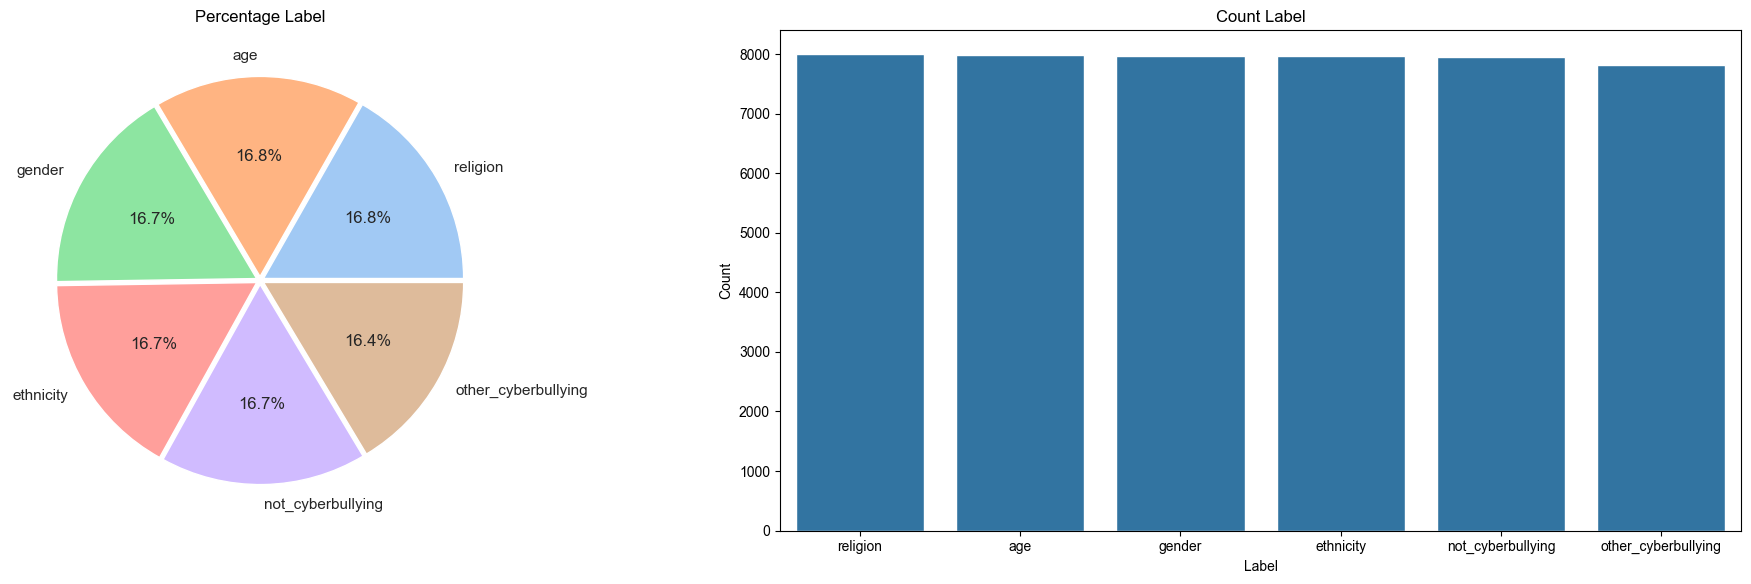

In [21]:
# Count occurrences of each label in 'cyberbullying_type' column
label_count = df['cyberbullying_type'].value_counts()

# Create subplots for pie chart and bar chart
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Set seaborn theme and palette
sb.set_theme(style='darkgrid', palette='pastel')

# Define colors and explode values for pie chart
color = sb.color_palette('pastel')
explode = [0.02] * len(label_count)

# Plot pie chart showing percentage of each label
axes[0].pie(label_count.values, labels=label_count.index, autopct='%1.1f%%', colors=color, explode=explode)
axes[0].set_title('Percentage Label')

# Plot bar chart showing count of each label
sb.barplot(x=label_count.index, y=label_count.values, ax=axes[1])
axes[1].set_title('Count Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

# Adjust layout to prevent overlapping of labels
plt.tight_layout()

# Display the plots
plt.show()

### Most Common Words by Tokenization
Here, we used tokenization to break down a piece of text like sentences or paragraphs into individual worlds or "tokens". From this plot, we can see the most common words in the tweets of our data.

In [24]:
from collections import Counter
import numpy as np

In [22]:
# Define a function to tokenize the text column
def Tokenize(column, seq_len):
    # Create a corpus of words from the text column
    corpus = [word for text in column for word in text.split()]

    # Count the occurrences of each word in the corpus
    count_words = Counter(corpus)

    # Sort words based on their frequencies
    sorted_words = count_words.most_common()

    # Assign unique integer indices to words
    vocab_to_int = {w: i + 1 for i, (w, c) in enumerate(sorted_words)}

    # Tokenize each text in the column using the vocabulary
    text_int = []
    for text in column:
        r = [vocab_to_int[word] for word in text.split()]
        text_int.append(r)

    # Pad/truncate sequences to match the specified sequence length
    features = np.zeros((len(text_int), seq_len), dtype=int)
    for i, review in enumerate(text_int):
        if len(review) <= seq_len:
            zeros = list(np.zeros(seq_len - len(review)))
            new = zeros + review
        else:
            new = review[: seq_len]
        features[i, :] = np.array(new)

    return sorted_words, features

#### Simple test of Tokenize Function

In [25]:
# Sample
sample_texts = [
    "you are stupid",
    "i hate you",
    "you are very stupid"
]

# Manually Count
corpus = []
for text in sample_texts:
    for word in text.split():
        corpus.append(word)

count_words = Counter(corpus)
sorted_words_manual = count_words.most_common()

print("Manual Sorted Words:")
print(sorted_words_manual)

# Manually map vocabulary
vocab_to_int_manual = {}
for i, (word, _) in enumerate(sorted_words_manual):
    vocab_to_int_manual[word] = i + 1

print("\nManual Vocab Mapping:")
print(vocab_to_int_manual)

# Manual tokenization
text_int_manual = []
for text in sample_texts:
    tokens = []
    for word in text.split():
        tokens.append(vocab_to_int_manual[word])
    text_int_manual.append(tokens)

# Manual Padding
seq_len = 5
features_manual = np.zeros((len(text_int_manual), seq_len), dtype=int)

for i, review in enumerate(text_int_manual):
    if len(review) <= seq_len:
        zeros = list(np.zeros(seq_len - len(review)))
        new = zeros + review
    else:
        new = review[:seq_len]
    features_manual[i, :] = np.array(new)

print("\nManual Tokenized & Padded Features:")
print(features_manual)

Manual Sorted Words:
[('you', 3), ('are', 2), ('stupid', 2), ('i', 1), ('hate', 1), ('very', 1)]

Manual Vocab Mapping:
{'you': 1, 'are': 2, 'stupid': 3, 'i': 4, 'hate': 5, 'very': 6}

Manual Tokenized & Padded Features:
[[0 0 1 2 3]
 [0 0 4 5 1]
 [0 1 2 6 3]]


In [26]:
# Test the function
sorted_words, features = Tokenize(sample_texts, seq_len=5)

print("\nSorted Words (by frequency):")
print(sorted_words)

print("\nTokenized & Padded Features:")
print(features)


Sorted Words (by frequency):
[('you', 3), ('are', 2), ('stupid', 2), ('i', 1), ('hate', 1), ('very', 1)]

Tokenized & Padded Features:
[[0 0 1 2 3]
 [0 0 4 5 1]
 [0 1 2 6 3]]


#### Apply Tokenizer Function

C:\Users\user\AppData\Local\Temp\ipykernel_1392\1045715215.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.barplot(x=keys, y=values, palette='mako')


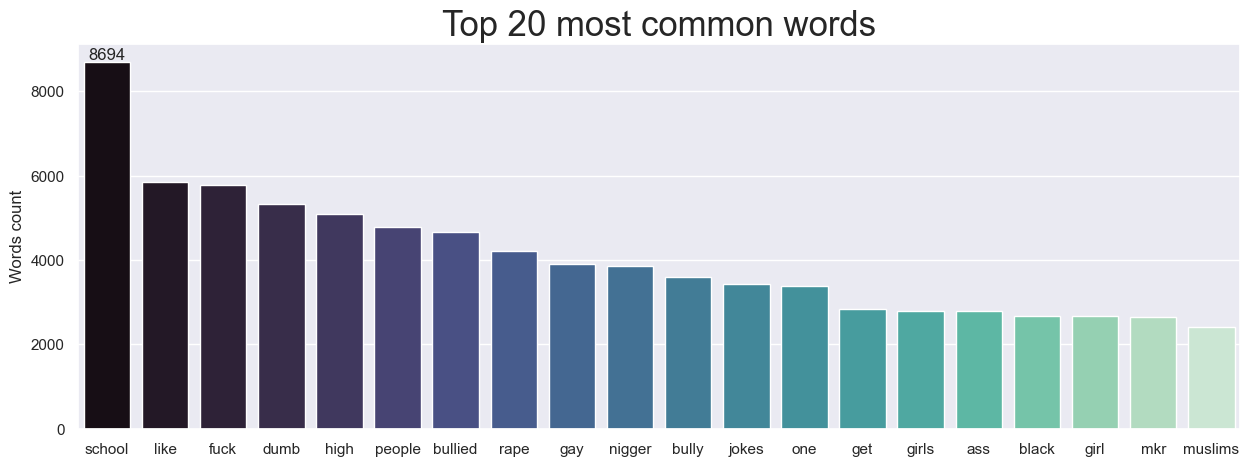

In [27]:
# Tokenize the tweet_clean column
vocabulary, tokenized_column = Tokenize(df["tweet_clean"], 300)

# Extract the top 20 most common words and their frequencies from the vocabulary
keys = []
values = []
for key, value in vocabulary[:20]:
    keys.append(key)
    values.append(value)

# Plotting the top 20 most common words
plt.figure(figsize=(15, 5))
ax = sb.barplot(x=keys, y=values, palette='mako')
plt.title('Top 20 most common words', size=25)
ax.bar_label(ax.containers[0])
plt.ylabel("Words count")
plt.show()

### Word Cloud
For this section, we used a WordCloud to present the most commonly seen words according to each classified category. The presence of each words in a tweet will increase its corresponding probability towards being classified into its respective category.

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#### Function to generating Word Cloud 

In [29]:
def word_cloud(data):
    # Filter text data for a specific cyberbullying type
    text = df[df['cyberbullying_type'] == data]

    # Concatenate all cleaned tweets into a single string
    text_cloud = " ".join(txt for txt in text['tweet_clean'])

    # Generate word cloud
    cloud = WordCloud(collocations=False, background_color='white').generate(text_cloud)

    # Display the word cloud
    plt.imshow(cloud)
    plt.axis('off')  # Hide axis

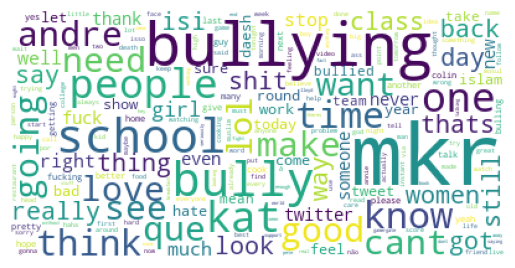

In [30]:
word_cloud('not_cyberbullying')

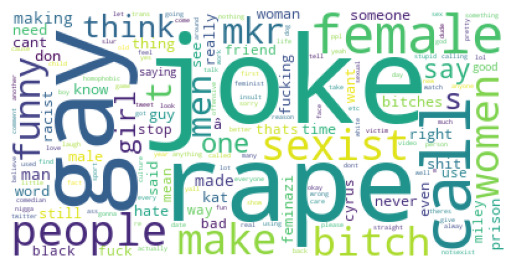

In [18]:

word_cloud('gender')

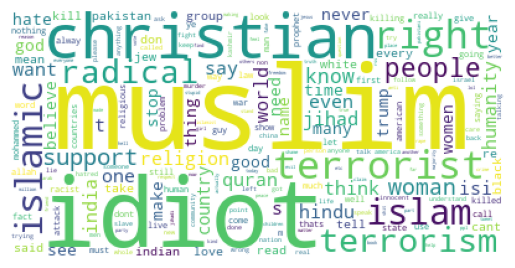

In [19]:
word_cloud('religion')

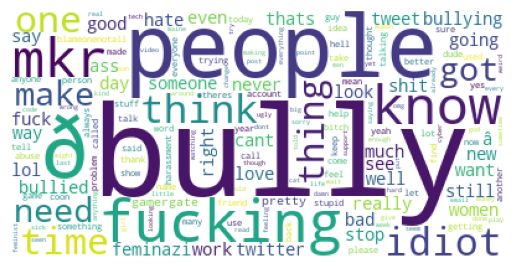

In [20]:
word_cloud('other_cyberbullying')

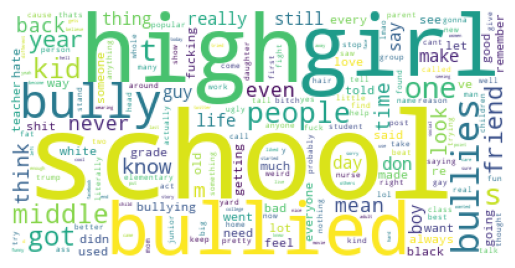

In [21]:
word_cloud('age')

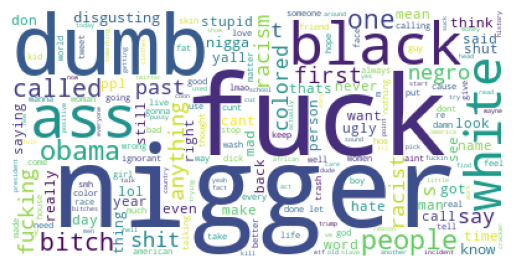

In [22]:
word_cloud('ethnicity')

### Sentiment Analysis
For sentiment analysis, we used the the module `TextBlob` for natural language processing tasks. The sentiment analysis model considers various factors such as: 

- word polarity
- intensity of sentiment
- context 

This is to determine the sentiment score for a given text. This would help us in identifying sentiments - positive, negative and neutral; from a piece of text.

The sentiment score represents the polarity of the text (Positive, Negative, Neutral). It is a floating point number ranging from -1.0 to +1.0.

> - If the sentiment score is close to 1.0, it indicates a very positive sentiment.
> - If the sentiment score is close to -1.0, it indicates a very negative sentiment.
> - If the sentiment score is around 0.0, it indicates a neutral sentiment.

In [31]:
from textblob import TextBlob

In [32]:
def analyze_sentiment(data):
    sentiments = []
    text = df[df['cyberbullying_type'] == data]
    # Concatenate cleaned tweets into a single string
    text_cloud = " ".join(txt for txt in text['tweet_clean'])
    # Iterate over cleaned tweets
    for tweet in text['tweet_clean']:
        blob = TextBlob(tweet)
        sentiment_score = abs(blob.sentiment.polarity)  # Get absolute value of sentiment polarity
        sentiments.append(sentiment_score)
    return sentiments

In [33]:
# Call the function for each cyberbullying type
not_cyberbullying = analyze_sentiment('not_cyberbullying')
gender = analyze_sentiment('gender')
religion = analyze_sentiment('religion')
other_cyberbullying = analyze_sentiment('other_cyberbullying')
age = analyze_sentiment('age')
ethnicity = analyze_sentiment('ethnicity')

# Print average sentiment scores for each type
print("Average sentiment score for cyberbullying tweets:", (sum(gender)+sum(religion)+sum(age)+sum(ethnicity)+sum(other_cyberbullying)) / (len(gender)+len(religion)+len(age)+len(ethnicity)+len(other_cyberbullying)))
print("Average sentiment score for not_cyberbullying tweets:", sum(not_cyberbullying) / len(not_cyberbullying))
print()
print("Average sentiment score for gender cyberbullying tweets:", sum(gender) / len(gender))
print("Average sentiment score for religion cyberbullying tweets:", sum(religion) / len(religion))
print("Average sentiment score for age cyberbullying tweets:", sum(age) / len(age))
print("Average sentiment score for ethnicity cyberbullying tweets:", sum(ethnicity) / len(ethnicity))
print("Average sentiment score for other_cyberbullying cyberbullying tweets:", sum(other_cyberbullying) / len(other_cyberbullying))

Average sentiment score for cyberbullying tweets: 0.23193334278478747
Average sentiment score for not_cyberbullying tweets: 0.18029953528919926

Average sentiment score for gender cyberbullying tweets: 0.2242584434469134
Average sentiment score for religion cyberbullying tweets: 0.23840078967838282
Average sentiment score for age cyberbullying tweets: 0.1746563899728508
Average sentiment score for ethnicity cyberbullying tweets: 0.27123820846987645
Average sentiment score for other_cyberbullying cyberbullying tweets: 0.2516593690304602


## Machine Learning
Machine learning is a branch of artificial intelligence that focuses on developing algorithms and statistical models that allow us to learn from our data and make any predicitons or decisions without explicitly programming it. 

Machine learning can identify patterns across large datasets that is impossible for the human to do so efficiently. The machine's performance can also be improved over time as they are more exposed to more data or by fine-tuning certain parameters.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score ,classification_report,confusion_matrix
import joblib
import seaborn as sb
import matplotlib.pyplot as plt

In [35]:
x = df['tweet_clean']
y,class_names = pd.factorize(df['cyberbullying_type'],sort=True)

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=5)

x_train = []
for x in X_train:
    x_train.append(str(x))

x_test = []
for x in X_test:
    x_test.append(str(x))

### Classifier Report Function

In [39]:
def Classifier(model):
    # Initialize a TfidfVectorizer
    vectorizer = TfidfVectorizer()

    # Fit the vectorizer on the cleaned tweet data
    vectorizer.fit(df['tweet_clean'])

    # Transform training and testing data to TF-IDF vectors
    x_train_vecs = vectorizer.transform(x_train)
    x_test_vecs = vectorizer.transform(x_test)

    # Train the model on the TF-IDF vectors of the training data
    model.fit(x_train_vecs, y_train)

    # Predict the labels for the testing data
    y_pred = model.predict(x_test_vecs)

    # Print accuracy score and classification report
    print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))
    print()
    print("Classification Report: \n", classification_report(y_test, y_pred))

    # Generate confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix as a heatmap
    sb.heatmap(conf_matrix, annot=True, fmt='d', cmap=None, xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

### Classifier Report Function (To replace the old one subsequently)

In [40]:
def Classifier(
    model=None,
    mode="train",
    model_path="model.pkl",
    vectorizer_path="vectorizer.pkl"
):
    """
    mode="train" -> train model and save model + vectorizer
    mode="load"  -> load saved model + vectorizer, no retraining
    """

    if mode == "train":
        # Create and fit TF-IDF vectorizer on training data only
        vectorizer = TfidfVectorizer()
        x_train_vecs = vectorizer.fit_transform(x_train)
        x_test_vecs = vectorizer.transform(x_test)

        model.fit(x_train_vecs, y_train)

        # Save trained model and fitted vectorizer
        joblib.dump(model, model_path)
        joblib.dump(vectorizer, vectorizer_path)

        print(f"Saved model to: {model_path}")
        print(f"Saved vectorizer to: {vectorizer_path}")

    elif mode == "load":
        # Load saved model and fitted vectorizer
        model = joblib.load(model_path)
        vectorizer = joblib.load(vectorizer_path)

        # Transform test text using loaded vectorizer
        x_test_vecs = vectorizer.transform(x_test)

        print(f"Loaded model from: {model_path}")
        print(f"Loaded vectorizer from: {vectorizer_path}")

    else:
        raise ValueError("Mode must be 'train' or 'load'")

    y_pred = model.predict(x_test_vecs)

    print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))
    print()
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Plot confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    sb.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap=None,
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return model, vectorizer, y_pred

### **Naive Bayes Model**
Naive Bayes Model is a simple yet powerful machine learning algorithm used for NLP applications like text classification tasks, particularly in natural language processing (NLP). It's based on Bayes' theorem with the "naive" assumption of feature independence. Despite its simplicity, Naive Bayes often performs well in practice. In our classification, it performs moderately accurate.

Saved model to: .\Artifacts\naive_bayes_model.pkl
Saved vectorizer to: .\Artifacts\naive_bayes_vectorizer.pkl
Accuracy: 0.728

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.99      0.79      1952
           1       0.82      0.91      0.86      1995
           2       0.79      0.82      0.81      1952
           3       0.65      0.34      0.45      2040
           4       0.60      0.36      0.45      2006
           5       0.77      0.97      0.86      1978

    accuracy                           0.73     11923
   macro avg       0.71      0.73      0.70     11923
weighted avg       0.71      0.73      0.70     11923



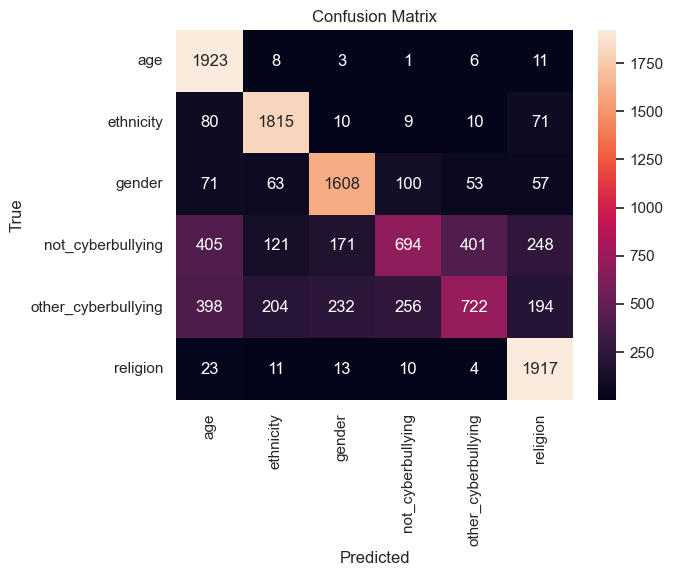

In [38]:
from sklearn.naive_bayes import MultinomialNB

# Initialize Multinomial Naive Bayes model pass it to the Classifier function
model = MultinomialNB()

nb_model, nb_vectorizer, nb_y_pred = Classifier(
    model=model,
    mode="train",
    model_path=r".\Artifacts\naive_bayes_model.pkl",
    vectorizer_path=r".\Artifacts\naive_bayes_vectorizer.pkl"
)

**ROC Curve** 
 
The ROC curve illustrates the balance between true positive rate (TPR) and false positive rate (FPR) across different thresholds. A model excels when its curve hugs the top-left corner, indicating high TPR and low FPR. Conversely, a curve closer to the diagonal line signifies poor ability to discriminate, no better than random chance.

In [20]:
#ROC Curve

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [21]:
#Define Class Labels
class_labels = [ 'age', 'gender', 'ethnicity', 'not_cyberbullying','other_cyberbullying', 'religion']

def plot_roc_curves(model, x_test, y_test):
    # Get the number of classes
    num_classes = len(np.unique(y_test))

    # Initialize the figure
    plt.figure(figsize=(8, 6))

    # Plot ROC curve for each class
    for i in range(num_classes):
        # Treat the current class as positive and the rest as negative
        y_true_class = np.where(y_test == i, 1, 0)

        # Predict probabilities for the current class
        y_probs_class = model.predict_proba(x_test)

        # Calculate false positive rate and true positive rate
        fpr, tpr, _ = roc_curve(y_true_class, y_probs_class[:, i])

        # Calculate area under the curve
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve for the current class
        plt.plot(fpr, tpr, lw=2, label='ROC curve for {} (area = {:.2f})'.format(class_labels[i], roc_auc))

    # Plot random guess line
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')

    # Set plot labels and title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.show()

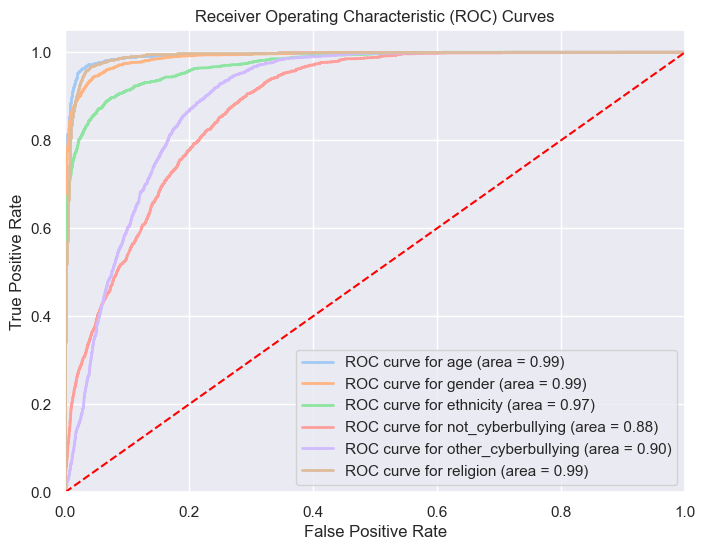

In [22]:
# Call the function with your trained model and test data
vectorizer   = TfidfVectorizer()
vectorizer.fit(df['tweet_clean'])
x_test_vecs  = vectorizer.transform(x_test)
plot_roc_curves(model, x_test_vecs, y_test)

**Learning Curve**

A learning curve is a plot that shows how a model's performance, often measured by accuracy, changes as the size of the training dataset increases. It helps assess if the model benefits from more data and can reveal issues like overfitting or underfitting. Cross-validation scores are often included for a more reliable estimate of performance.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

In [24]:
def plot_learning_curve_multi_class(model, x_train, y_train, class_labels, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        model, x_train, y_train, train_sizes=train_sizes, cv=5, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.title("Learning Curve")
    plt.legend(loc="best")
    plt.grid()
    plt.show()


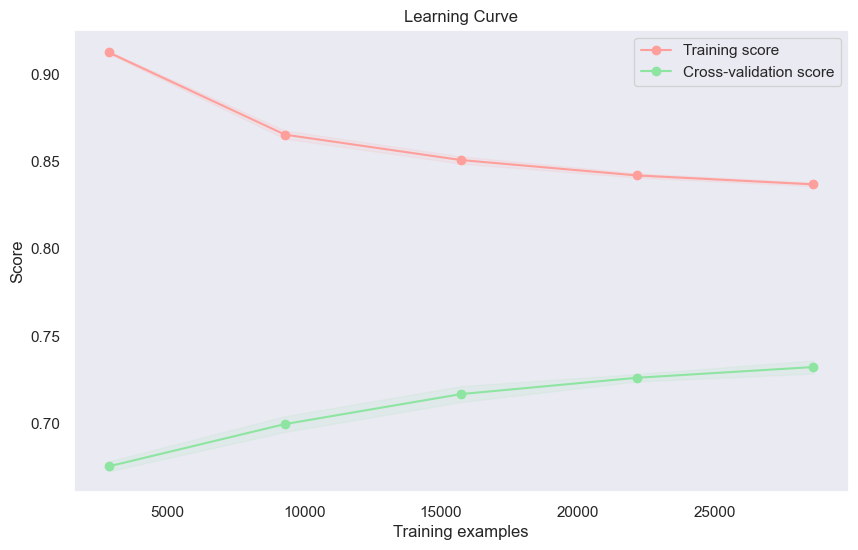

In [25]:
# Call the function with your trained model, training data, and class labels
x_train_vecs = vectorizer.transform(x_train)
plot_learning_curve_multi_class(model, x_train_vecs, y_train, class_labels)

*ADVANTAGES*

- Easy to understand and implement
- Can be trained quickly and make fast predictions
- Can solve multi-class prediction problems

*DISADVANTAGES*

- Lousy estimator

### **Multinomial Logistic Regression**
Multinomial Logistic Regression extends Logistic Regression to handle multi-class classification tasks by predicting probabilities for each class and selecting the class with the highest probability as the predicted output. he model shows good results in prediction of cyberbullying type in our tweets.


Accuracy: 0.813

Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      1952
           1       0.97      0.97      0.97      1995
           2       0.93      0.81      0.86      1952
           3       0.57      0.56      0.57      2040
           4       0.57      0.64      0.60      2006
           5       0.95      0.94      0.95      1978

    accuracy                           0.81     11923
   macro avg       0.82      0.81      0.82     11923
weighted avg       0.82      0.81      0.82     11923



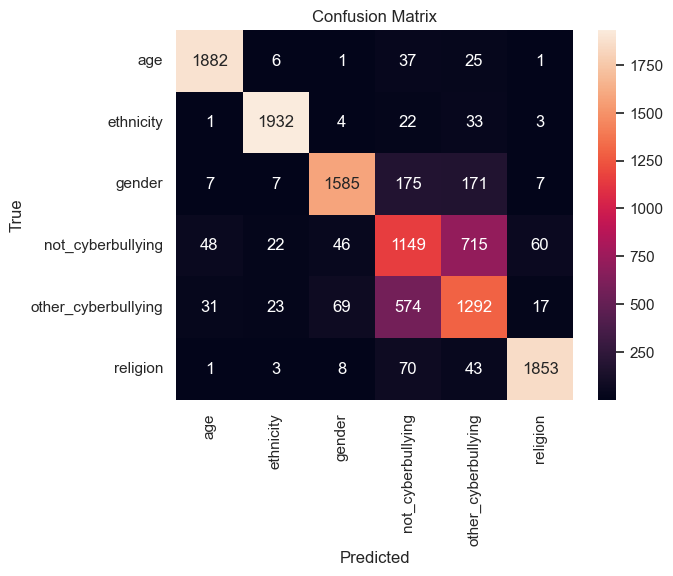

In [35]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model pass it to the Classifier function
model = LogisticRegression(max_iter=1000)
Classifier(model)

**ROC Curve**

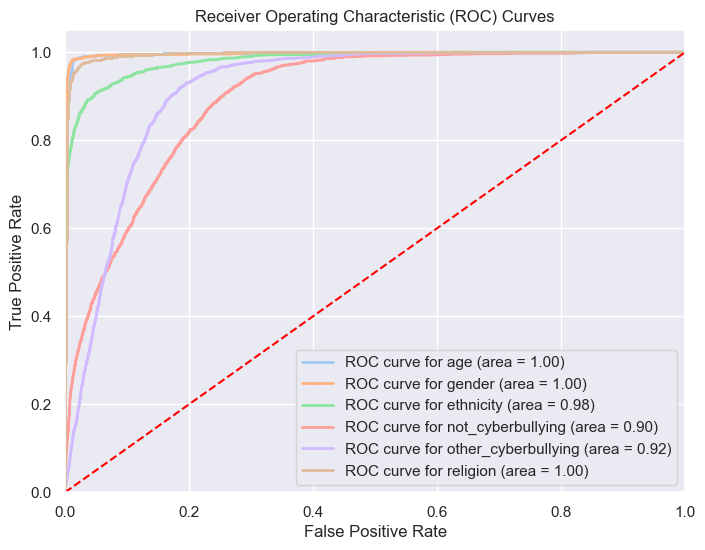

In [36]:
# Call the function with your trained model and test data
vectorizer   = TfidfVectorizer()
vectorizer.fit(df['tweet_clean'])
x_test_vecs  = vectorizer.transform(x_test)
plot_roc_curves(model, x_test_vecs, y_test)

**Learning Curve**

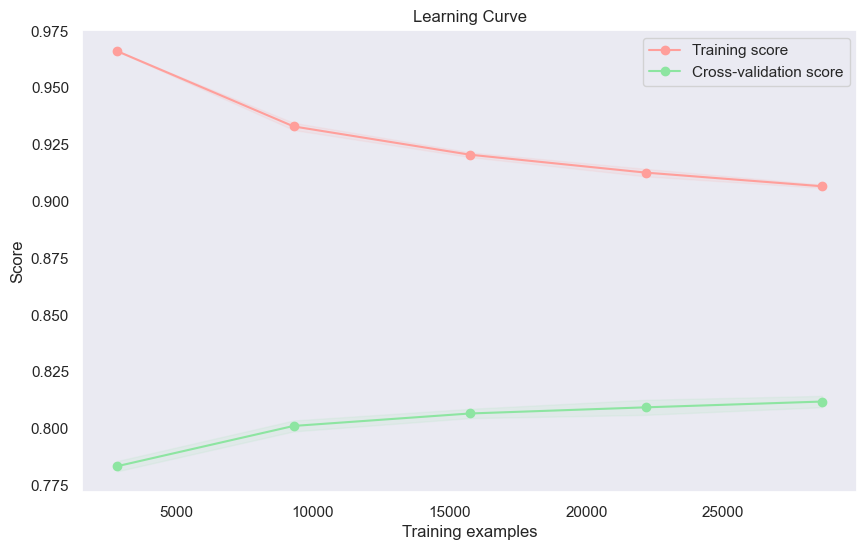

In [37]:
# Call the function with your trained model, training data, and class labels
x_train_vecs = vectorizer.transform(x_train)
plot_learning_curve_multi_class(model, x_train_vecs, y_train, class_labels)

*ADVANTAGES*

- Provides probabilities for each category, allowing for nuanced predictions and quantification of uncertainty.

- Enables decision-makers to assess the likelihood of different outcomes, aiding in informed decision-making.

- Facilitates understanding of how predictors influence category selection, enhancing model interpretability.

*DISADVANTAGES*

- Assumes independence of observations, which may not hold in all datasets.

- Violation can lead to biased parameter estimates and inaccurate inference.

- Typically needs a larger sample size compared to a binary logistic regression.

### **Support Vector Machine**

SVM classification finds the best hyperplane to separate data into different classes, maximizing the margin between them. It's effective for various classification tasks due to its ability to handle linear and non-linear separations through kernel functions.

Accuracy: 0.811

Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.97      0.97      1952
           1       0.97      0.97      0.97      1995
           2       0.93      0.80      0.86      1952
           3       0.58      0.49      0.53      2040
           4       0.54      0.71      0.61      2006
           5       0.97      0.93      0.95      1978

    accuracy                           0.81     11923
   macro avg       0.83      0.81      0.82     11923
weighted avg       0.82      0.81      0.81     11923



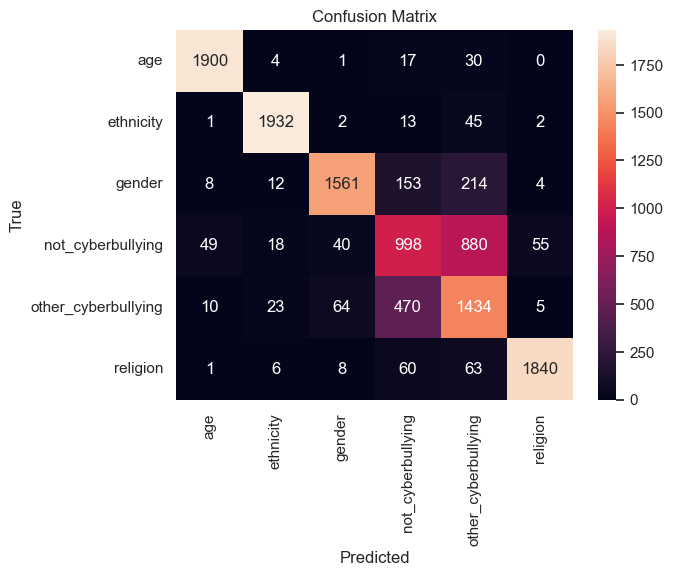

In [33]:
from sklearn.svm import SVC

model = SVC(probability=True)
Classifier(model)

**ROC Curve**

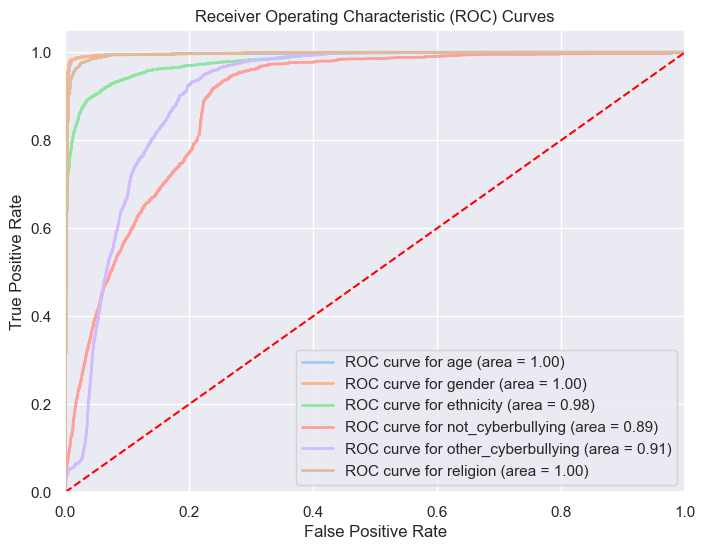

In [34]:
plot_roc_curves(model, x_test_vecs, y_test)

**Learning Curve**

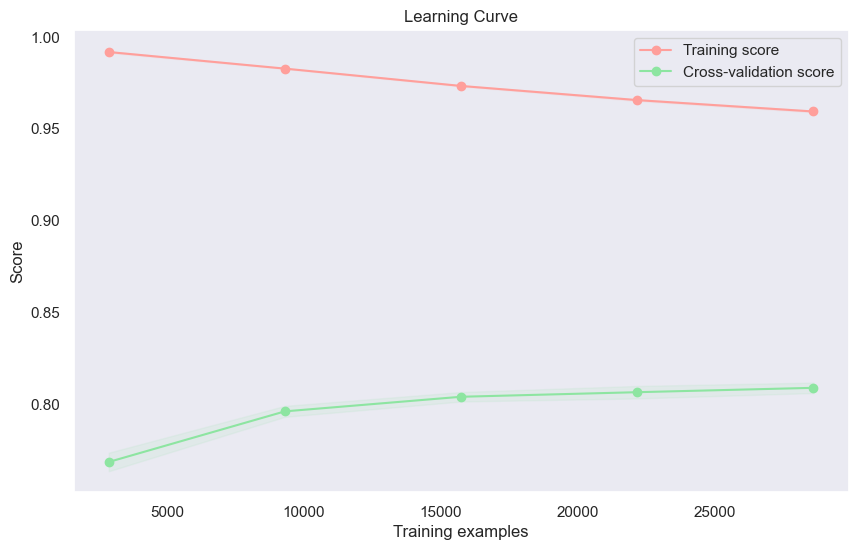

In [37]:
plot_learning_curve_multi_class(model, x_train_vecs, y_train, class_labels)

*ADVANTAGES*

- Performs well even in high-dimensional spaces, making it suitable for complex datasets.

- Aims to maximize the margin between classes, leading to a more generalizable model and reducing the risk of overfitting.

- Can handle non-linear decision boundaries using kernel functions like polynomial, radial basis function (RBF), and sigmoid, providing flexibility in modeling complex relationships.

*DISADVANTAGES*

- Training models can be computationally intensive, especially for large datasets.

- SVM is sensitive to noisy data and outliers, which can affect the placement of the decision boundary and degrade performance.

- The decision boundary produced by SVM may be difficult to interpret, especially in higher dimensions or with non-linear kernels, making it challenging to understand the underlying relationships in the data.

### **Random Forest**

Random Forest Classifier is an ensemble learning technique for classification tasks, which builds multiple decision trees and outputs the mode of the classes predicted by individual trees. It's effective, versatile, and resistant to overfitting. The model shows good results in prediction of cyberbullying type in our tweets.

Accuracy: 0.812

Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      1952
           1       0.98      0.98      0.98      1995
           2       0.90      0.83      0.86      1952
           3       0.58      0.46      0.51      2040
           4       0.53      0.68      0.60      2006
           5       0.95      0.96      0.95      1978

    accuracy                           0.81     11923
   macro avg       0.82      0.81      0.81     11923
weighted avg       0.82      0.81      0.81     11923



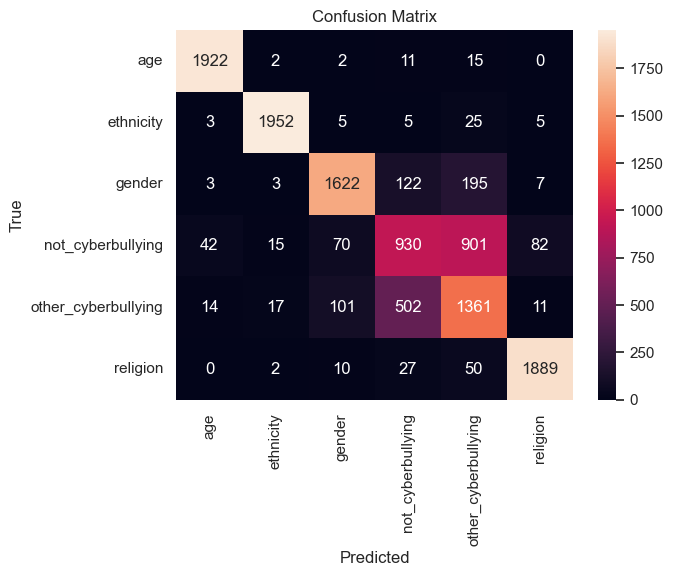

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier model pass it to the Classifier function
model=RandomForestClassifier()
Classifier(model)

**ROC Curve**

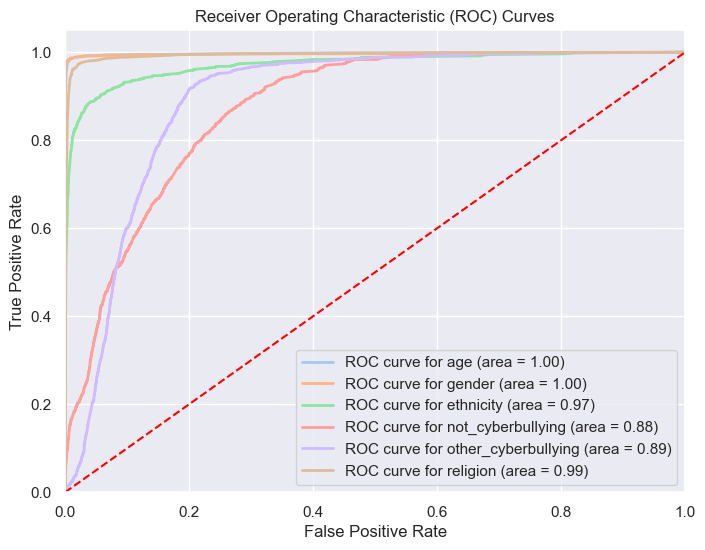

In [27]:
plot_roc_curves(model, x_test_vecs, y_test)

**Learning Curve**

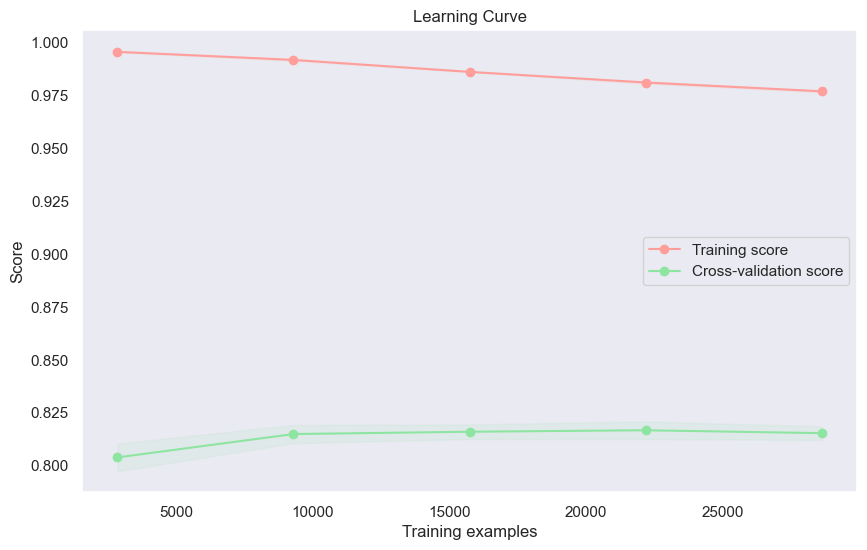

In [28]:
plot_learning_curve_multi_class(model, x_train_vecs, y_train, class_labels)

*ADVANTAGES*

- Often produces highly accurate predictions, even without extensive hyperparameter tuning.

- By aggregating predictions from multiple decision trees, Random Forest is less prone to overfitting compared to individual decision trees.

- Random Forest can efficiently handle large datasets with many features and instances, making it suitable for complex problems.

- Can handle missing values in the dataset without the need for imputation, reducing preprocessing requirements.

*DISADVANTAGES*

- The ensemble nature of it makes it less interpretable compared to simpler models, as it's challenging to trace predictions back to individual trees.

- Training this model can be computationally expensive, especially for large datasets with numerous trees and deep trees.

- Random Forest tends to be biased towards the majority class in imbalanced datasets, potentially leading to suboptimal performance for minority classes.

### **What is Bi-LSTM?**
LSTM (Long Short-Term Memory) is a renowned type of recurrent neural network (RNN) used for processing sequential data and capturing long-term dependencies. We employ Bidirectional-LSTM (Bi-LSTM) to extend this capability by processing input sequences in both forward and backward directions, effectively capturing contextual information.

### **Architecture**

The model architecture incorporates:

- An input embedding layer initialized with pre-trained word embeddings from Word2Vec, capturing the semantic meanings of tweets;

- A core LSTM layer, processing input sequences bidirectionally to capture nuanced relationships between words;

- An attention mechanism, focusing on important parts of the input sequence and enhancing the model's classification performance.

### **Training Parameters**

During training, the model parameters are optimized using the AdamW optimizer and minimize the negative log-likelihood loss function (NLLLoss). We define hyperparameters such as:

*Number of classes:* 6

*Hidden dimensions:* 100

*Number of LSTM layers:* 1

*Dropout rate*

*Learning rate*

*Number of epochs:* 10

Epochs refer to the number of times the entire dataset is passed forward and backward through the neural network during training. We implement early stopping based on validation accuracy to prevent overfitting.

### **Model Evaluation**

The best-performing model, based on validation accuracy, is selected for evaluation. After training, we evaluate the model on the test data and compute the classification report. The model achieves an accuracy of 0.81, demonstrating the effectiveness of our LSTM-based approach in cyberbullying tweet classification.

In [ ]:
from gensim.models import Word2Vec

# Train Word2Vec model
Word2vec_train_data = list(map(lambda x: x.split(), x_train))
EMBEDDING_DIM = 200
word2vec_model = Word2Vec(Word2vec_train_data, vector_size=EMBEDDING_DIM)
print(f"Vocabulary size: {len(vocabulary) + 1}")

Vocabulary size: 53561


In [ ]:
# Define a function to map sentiment labels to numerical values
df['sentiment'] = df['cyberbullying_type'].replace({
    'religion': 5,
    'age': 0,
    'ethnicity': 1,
    'gender': 2,
    'not_cyberbullying': 3,
    'other_cyberbullying': 4
})

# Define embedding matrix
VOCAB_SIZE = len(vocabulary) + 1
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

# Fill the embedding matrix with pre-trained values from word2vec
for word, token in vocabulary:
    if word in word2vec_model.wv.key_to_index:
        embedding_vector = word2vec_model.wv[word]
        embedding_matrix[token] = embedding_vector
print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (53561, 200)


/tmp/ipykernel_4972/1845155236.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['cyberbullying_type'].replace({


### **Setting up Model Parameters and Architecture for Training**

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import RandomOverSampler
import torch

X = tokenized_column
y = df['sentiment'].astype(np.int64).to_numpy()

# Split data into train, test, and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=5)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2)

# Apply Random Over Sampling
ros = RandomOverSampler()
X_train_os, y_train_os = ros.fit_resample(X_train, y_train)

# Convert data into PyTorch DataLoader
BATCH_SIZE = 32
train_data = TensorDataset(torch.from_numpy(X_train_os), torch.from_numpy(y_train_os))
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
valid_data = TensorDataset(torch.from_numpy(X_valid), torch.from_numpy(y_valid))
train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE, drop_last=True)
valid_loader = DataLoader(valid_data, shuffle=False, batch_size=BATCH_SIZE, drop_last=True)
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE, drop_last=True)

In [ ]:
import torch.nn as nn

# Define the Attention module
class Attention(nn.Module):
    def __init__(self, hidden_dim, is_bidirectional):
        super(Attention, self).__init__()
        self.is_bidirectional = is_bidirectional
        self.attn = nn.Linear(hidden_dim * (4 if is_bidirectional else 2), hidden_dim * (2 if is_bidirectional else 1))
        self.v = nn.Linear(hidden_dim * (2 if is_bidirectional else 1), 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        seq_len = encoder_outputs.size(1)
        if self.is_bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=-1)
        else:
            hidden = hidden[-1]
        hidden_repeated = hidden.unsqueeze(1).repeat(1, seq_len, 1)
        attn_weights = torch.tanh(self.attn(torch.cat((hidden_repeated, encoder_outputs), dim=2)))
        attn_weights = self.v(attn_weights).squeeze(2)
        return nn.functional.softmax(attn_weights, dim=1)

# Define the LSTM Sentiment Classifier
class LSTM_Sentiment_Classifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, lstm_layers, dropout, is_bidirectional):
        super(LSTM_Sentiment_Classifier, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = lstm_layers
        self.is_bidirectional = is_bidirectional

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, lstm_layers, batch_first=True, bidirectional=is_bidirectional)
        self.attention = Attention(hidden_dim, is_bidirectional)
        self.fc = nn.Linear(hidden_dim * (2 if is_bidirectional else 1), num_classes)
        self.softmax = nn.LogSoftmax(dim=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        out, hidden = self.lstm(embedded, hidden)
        attn_weights = self.attention(hidden[0], out)
        context = attn_weights.unsqueeze(1).bmm(out).squeeze(1)
        out = self.softmax(self.fc(context))
        return out, hidden

    def init_hidden(self, batch_size):
        factor = 2 if self.is_bidirectional else 1
        h0 = torch.zeros(self.num_layers * factor, batch_size, self.hidden_dim).to(DEVICE)
        c0 = torch.zeros(self.num_layers * factor, batch_size, self.hidden_dim).to(DEVICE)

In [ ]:
NUM_CLASSES = 6
HIDDEN_DIM = 100
LSTM_LAYERS = 1
IS_BIDIRECTIONAL = False
LR = 4e-4
DROPOUT = 0.5
EPOCHS = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = LSTM_Sentiment_Classifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_CLASSES, LSTM_LAYERS, DROPOUT, IS_BIDIRECTIONAL)
model = model.to(DEVICE)

# Initialize the embedding layer with the previously defined embedding matrix
model.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
model.embedding.weight.requires_grad = True

# Set up the criterion (loss function) and optimizer
criterion = nn.NLLLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-6)
print(model)

LSTM_Sentiment_Classifier(
  (embedding): Embedding(53561, 200)
  (lstm): LSTM(200, 100, batch_first=True)
  (attention): Attention(
    (attn): Linear(in_features=200, out_features=100, bias=True)
    (v): Linear(in_features=100, out_features=1, bias=False)
  )
  (fc): Linear(in_features=100, out_features=6, bias=True)
  (softmax): LogSoftmax(dim=1)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
print(DEVICE)

cuda


### **Model Training**

In [ ]:
# Train the model
total_step = len(train_loader)
total_step_val = len(valid_loader)

early_stopping_patience = 4
early_stopping_counter = 0
valid_acc_max = 0

for e in range(EPOCHS):
    train_loss, valid_loss = [], []
    train_acc, valid_acc = [], []
    y_train_list, y_val_list = [], []
    correct, correct_val = 0, 0
    total, total_val = 0, 0
    running_loss, running_loss_val = 0, 0

    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        h = model.init_hidden(labels.size(0))
        model.zero_grad()
        output, h = model(inputs, h)
        loss = criterion(output, labels)
        loss.backward()
        running_loss += loss.item()
        optimizer.step()
        y_pred_train = torch.argmax(output, dim=1)
        y_train_list.extend(y_pred_train.squeeze().tolist())
        correct += torch.sum(y_pred_train == labels).item()
        total += labels.size(0)
    train_loss.append(running_loss / total_step)
    train_acc.append(100 * correct / total)

    with torch.no_grad():
        model.eval()
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            val_h = model.init_hidden(labels.size(0))
            output, val_h = model(inputs, val_h)
            val_loss = criterion(output, labels)
            running_loss_val += val_loss.item()
            y_pred_val = torch.argmax(output, dim=1)
            y_val_list.extend(y_pred_val.squeeze().tolist())
            correct_val += torch.sum(y_pred_val == labels).item()
            total_val += labels.size(0)
        valid_loss.append(running_loss_val / total_step_val)
        valid_acc.append(100 * correct_val / total_val)

    if np.mean(valid_acc) >= valid_acc_max:
        torch.save(model.state_dict(), './state_dict.pt')
        print(f'Epoch {e+1}:Validation accuracy increased ({valid_acc_max:.6f} --> {np.mean(valid_acc):.6f}).  Saving model ...')
        valid_acc_max = np.mean(valid_acc)
        early_stopping_counter = 0
    else:
        print(f'Epoch {e+1}:Validation accuracy did not increase')
        early_stopping_counter += 1

    if early_stopping_counter > early_stopping_patience:
        print('Early stopped at epoch :', e+1)
        break

    print(f'\tTrain_loss : {np.mean(train_loss):.4f} Val_loss : {np.mean(valid_loss):.4f}')
    print(f'\tTrain_acc : {np.mean(train_acc):.3f}% Val_acc : {np.mean(valid_acc):.3f}%')

Epoch 1:Validation accuracy increased (0.000000 --> 76.457399).  Saving model ...
	Train_loss : 0.8586 Val_loss : 0.5204
	Train_acc : 63.455% Val_acc : 76.457%
Epoch 2:Validation accuracy increased (76.457399 --> 78.825673).  Saving model ...
	Train_loss : 0.4467 Val_loss : 0.4696
	Train_acc : 79.008% Val_acc : 78.826%
Epoch 3:Validation accuracy increased (78.825673 --> 79.582399).  Saving model ...
	Train_loss : 0.3492 Val_loss : 0.4835
	Train_acc : 84.161% Val_acc : 79.582%
Epoch 4:Validation accuracy increased (79.582399 --> 80.605381).  Saving model ...
	Train_loss : 0.2568 Val_loss : 0.5114
	Train_acc : 89.404% Val_acc : 80.605%
Epoch 5:Validation accuracy did not increase
	Train_loss : 0.1898 Val_loss : 0.5902
	Train_acc : 92.160% Val_acc : 79.442%
Epoch 6:Validation accuracy did not increase
	Train_loss : 0.1499 Val_loss : 0.6379
	Train_acc : 93.809% Val_acc : 79.400%
Epoch 7:Validation accuracy did not increase
	Train_loss : 0.1260 Val_loss : 0.6991
	Train_acc : 94.657% Val_ac

### **Model Evaluation**

In [ ]:
model.load_state_dict(torch.load('./state_dict.pt'))
sentiments = ["age", "ethnicity", "gender", "other_cyberbullying", "not bullying","religion"]

def evaluate_model(model, test_loader):
    model.eval()
    y_pred_list = []
    y_test_list = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            test_h = model.init_hidden(labels.size(0))
            output, val_h = model(inputs, test_h)
            y_pred_test = torch.argmax(output, dim=1)
            y_pred_list.extend(y_pred_test.squeeze().tolist())
            y_test_list.extend(labels.squeeze().tolist())
    return y_pred_list, y_test_list

y_pred_list, y_test_list = evaluate_model(model, test_loader)
print('Classification Report for Bi-LSTM :\n', classification_report(y_test_list, y_pred_list, target_names=sentiments))

Classification Report for Bi-LSTM :
                      precision    recall  f1-score   support

                age       0.97      0.96      0.97      1952
          ethnicity       0.97      0.95      0.96      1991
             gender       0.89      0.81      0.85      1950
other_cyberbullying       0.60      0.44      0.51      2034
       not bullying       0.55      0.75      0.64      2003
           religion       0.91      0.95      0.93      1974

           accuracy                           0.81     11904
          macro avg       0.82      0.81      0.81     11904
       weighted avg       0.81      0.81      0.81     11904



*ADVANTAGES*

- Proccesses input sequences in both forward and backward directions helps in understanding the complete context of the input sequence.

- Well-suited for capturing long-term dependencies in sequential data and can effectively model complex dependencies over extended sequences.

- Random Forest can efficiently handle large datasets with many features and instances, making it suitable for complex problems.

- The gated architecture of LSTM cells helps mitigate the vanishing gradient problem, making it more capable of learning and retaining information over long sequences.

*DISADVANTAGES*

- Effectively doubles the computational cost of processing each input sequence compared to unidirectional LSTMs.

- Require more memory to store the activations and gradients for both forward and backward processing directions.

- Complex models with multiple layers and bidirectional processing, make them less interpretable compared to simpler models.

- Prone to overfitting, especially when trained on small datasets or when the model capacity is too high relative to the dataset size.

### Comparison of Results

\begin{array}{cccccc}
\text{PARAMETER} & \text{Naive Bayes} & \text{Logistic Regression} & \text{SVM} & \text{Random Forest} & \text{Bi-LSTM} \\
\text{Accuracy} & 0.728 & 0.813 & 0.811 & 0.812 & 0.81 \\
\text{Precision} & 0.71 & 0.82 & 0.82 & 0.82 & 0.81 \\
\text{Recall} & 0.73 & 0.81 & 0.81 & 0.81 & 0.81 \\
\text{F1-Score} & 0.70 & 0.82 & 0.81 & 0.81 & 0.81 \\
\text{Support} & 11923 & 11923 & 11923 & 11923 & 11904 \\
\text{Running Time} & 5\text{-}10s & 1.5\text{-}2min & 20\ \text{min} & 30\ \text{min} & 2\ \text{hours} \\
\end{array}

Trading off both running time and predictive performance, Logistic Regression appears to be the most efficient model for this dataset. It achieves the highest F1-score (0.82) with significantly lower training time compared to more complex models such as SVM, Random Forest, and Bi-LSTM.

However, Bi-LSTM, due to its ability to capture sequential and contextual information, may generalize better to more complex or unseen data if trained further or on larger datasets.

\begin{array}{ccccccc}
\text{PRECISION} & \text{Religion} & \text{Age} & \text{Ethnicity} & \text{Gender} & \text{Other Cyberbullying} & \text{Not Cyberbullying} \\
\text{Naive Bayes} & 0.77 & 0.66 & 0.82 & 0.79 & 0.60 & 0.65 \\
\text{Logistic Regression} & 0.96 & 0.96 & 0.97 & 0.93 & 0.57 & 0.57 \\
\text{SVM} & 0.97 & 0.96 & 0.97 & 0.93 & 0.53 & 0.58 \\
\text{Random Forest} & 0.95 & 0.97 & 0.98 & 0.90 & 0.53 & 0.58 \\
\text{Bi-LSTM} & 0.91 & 0.97 & 0.97 & 0.89 & 0.60 & 0.55 \\
\end{array}

We can infer that the classification models are generally strong in identifying explicit forms of cyberbullying, such as religion, age, ethnicity, and gender-based categories. This is reflected by their consistently high precision scores (typically above 0.90). However, they struggle to accurately classify more ambiguous categories, such as other cyberbullying and non-cyberbullying, where precision drops significantly.

These patterns are further supported by the confusion matrices, which show substantial misclassification between these ambiguous classes. The ROC and learning curves also supports this, which indicate similar performance trends across models.

## Structured Error Analysis